In [79]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

In [5]:
df=pd.read_csv("Credit risk assesment.csv")

In [6]:
df.head()

,customer_id,name,age,gender,owns_car,owns_house,no_of_children,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,default_in_last_6months,credit_card_default
0,CST_115179,ita Bose,46,F,N,Y,0.0,107934.04,612.0,Unknown,1.0,1.0,33070.28,18690.93,73,544.0,2,1,1
1,CST_121920,Alper Jonathan,29,M,N,Y,0.0,109862.62,2771.0,Laborers,2.0,0.0,15329.53,37745.19,52,857.0,0,0,0
2,CST_109330,Umesh Desai,37,M,N,Y,0.0,230153.17,204.0,Laborers,2.0,0.0,48416.60,41598.36,43,650.0,0,0,0
3,CST_128288,Rie,39,F,N,Y,0.0,122325.82,11941.0,Core staff,2.0,0.0,22574.36,32627.76,20,754.0,0,0,0
4,CST_151355,McCool,46,M,Y,Y,0.0,387286.00,1459.0,Core staff,1.0,0.0,38282.95,52950.64,75,927.0,0,0,0


In [7]:
df.shape

(45528, 19)

In [8]:
df=df.drop(columns=['customer_id','name'])

In [9]:
df.shape

(45528, 17)

In [10]:
le=LabelEncoder()
for col in ['gender', 'owns_car', 'owns_house','occupation_type']:
    df[col] = le.fit_transform(df[col])

In [11]:
print(df.dtypes)

age                          int64
gender                       int64
owns_car                     int64
owns_house                   int64
no_of_children             float64
net_yearly_income          float64
no_of_days_employed        float64
occupation_type              int64
total_family_members       float64
migrant_worker             float64
yearly_debt_payments       float64
credit_limit               float64
credit_limit_used(%)         int64
credit_score               float64
prev_defaults                int64
default_in_last_6months      int64
credit_card_default          int64
dtype: object


In [12]:
df.isna().sum()

age                          0
gender                       0
owns_car                     0
owns_house                   0
no_of_children             774
net_yearly_income            0
no_of_days_employed        463
occupation_type              0
total_family_members        83
migrant_worker              87
yearly_debt_payments        95
credit_limit                 0
credit_limit_used(%)         0
credit_score                 8
prev_defaults                0
default_in_last_6months      0
credit_card_default          0
dtype: int64

In [13]:
cols_with_missing = ['no_of_children', 'no_of_days_employed', 
                     'yearly_debt_payments', 'migrant_worker',
                     'total_family_members', 'credit_score']

In [14]:
for col in cols_with_missing:
    df[col].fillna(df[col].median(), inplace=True)

In [15]:
df.isna().sum()

age                        0
gender                     0
owns_car                   0
owns_house                 0
no_of_children             0
net_yearly_income          0
no_of_days_employed        0
occupation_type            0
total_family_members       0
migrant_worker             0
yearly_debt_payments       0
credit_limit               0
credit_limit_used(%)       0
credit_score               0
prev_defaults              0
default_in_last_6months    0
credit_card_default        0
dtype: int64

In [16]:
print(df.shape)

(45528, 17)


In [17]:
df.head()

,age,gender,owns_car,owns_house,no_of_children,net_yearly_income,no_of_days_employed,occupation_type,total_family_members,migrant_worker,yearly_debt_payments,credit_limit,credit_limit_used(%),credit_score,prev_defaults,default_in_last_6months,credit_card_default
0,46,0,0,1,0.0,107934.04,612.0,17,1.0,1.0,33070.28,18690.93,73,544.0,2,1,1
1,29,1,0,1,0.0,109862.62,2771.0,8,2.0,0.0,15329.53,37745.19,52,857.0,0,0,0
2,37,1,0,1,0.0,230153.17,204.0,8,2.0,0.0,48416.60,41598.36,43,650.0,0,0,0
3,39,0,0,1,0.0,122325.82,11941.0,3,2.0,0.0,22574.36,32627.76,20,754.0,0,0,0
4,46,1,1,1,0.0,387286.00,1459.0,3,1.0,0.0,38282.95,52950.64,75,927.0,0,0,0


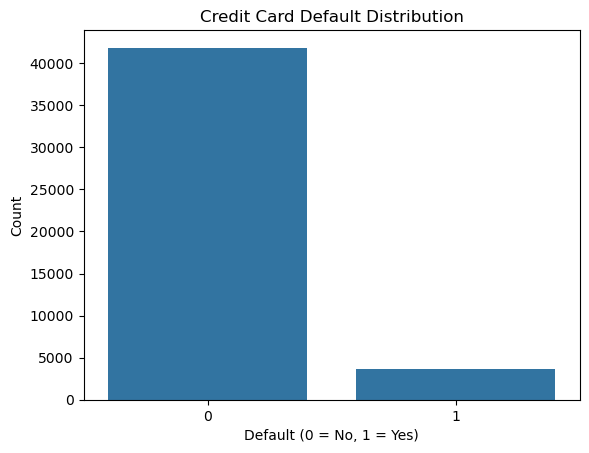

In [18]:
sns.countplot(x='credit_card_default', data=df)
plt.title('Credit Card Default Distribution')
plt.xlabel('Default (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

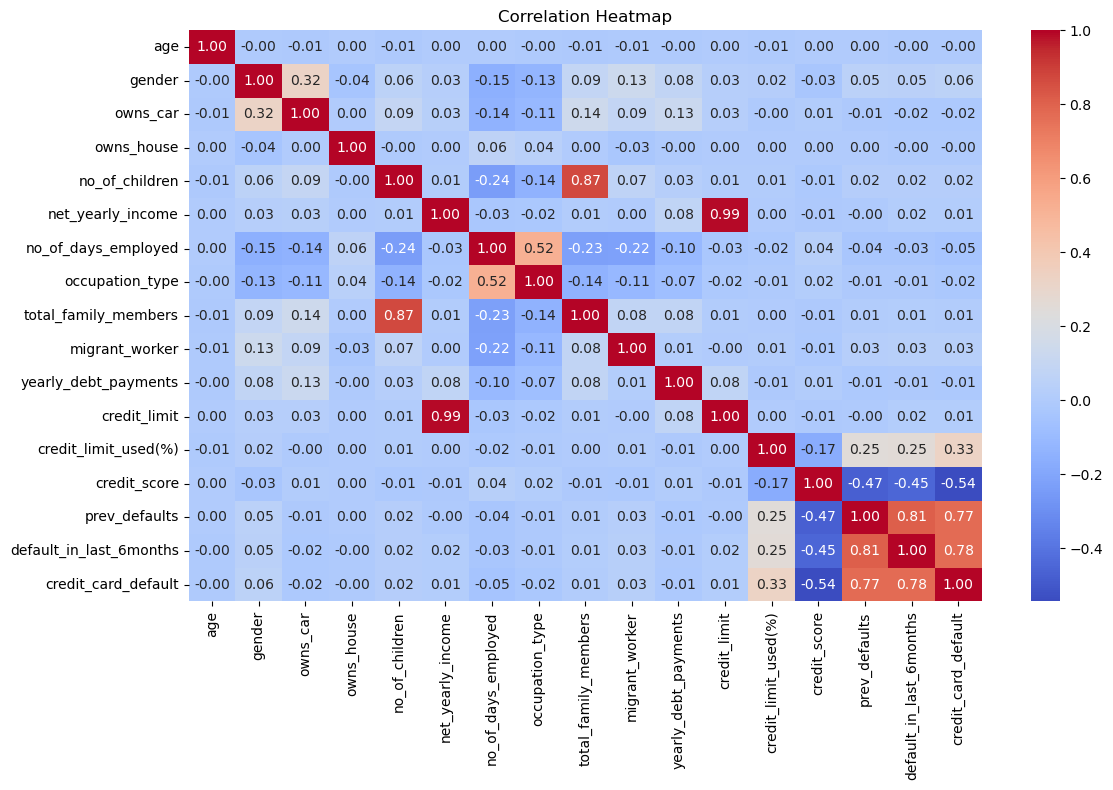

In [19]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

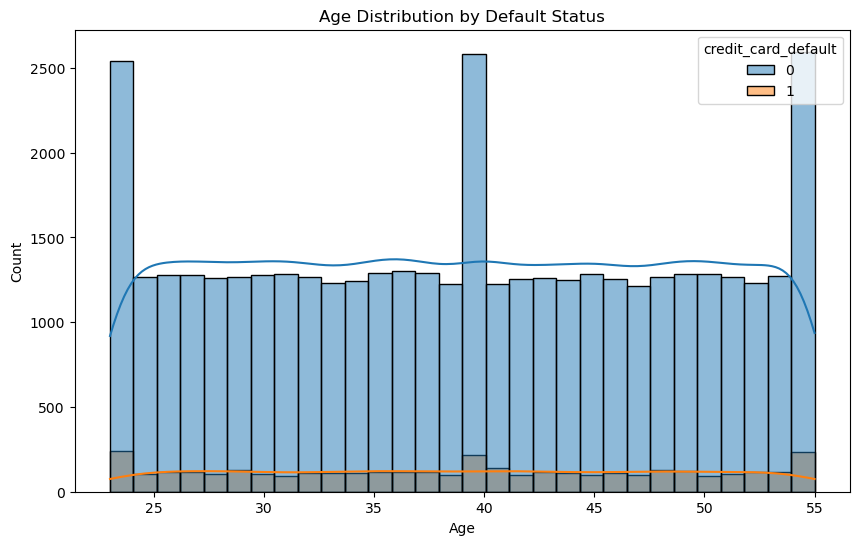

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='credit_card_default', 
             bins=30, kde=True)
plt.title('Age Distribution by Default Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

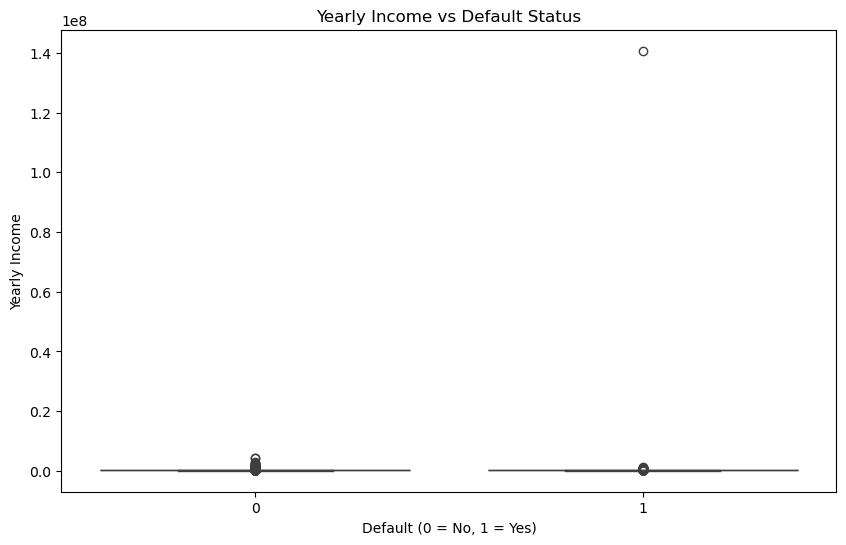

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='credit_card_default', y='net_yearly_income', data=df)
plt.title('Yearly Income vs Default Status')
plt.xlabel('Default (0 = No, 1 = Yes)')
plt.ylabel('Yearly Income')
plt.show()

In [22]:
X=df.drop(columns=['credit_card_default'])
Y=df['credit_card_default']

In [23]:
print(X.shape)

(45528, 16)


In [24]:
print(Y.shape)

(45528,)


In [25]:
X_train,X_test,Y_train, Y_test=train_test_split( X, Y, test_size=0.2, random_state=42)

In [26]:
X_train.shape

(36422, 16)

In [27]:
X_test.shape

(9106, 16)

In [37]:

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('Scaling done!')
print('X_train shape:', X_train.shape)

Scaling done!
X_train shape: (36422, 16)


In [43]:
model=LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train,Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [44]:
y_prd=model.predict(X_test)

In [48]:
print("Accuracy:",accuracy_score(Y_test,y_prd)*100,"%")
print("Classification_report")
classification_report(Y_test, y_prd)

Accuracy: 98.00131781243137 %
Classification_report


'              precision    recall  f1-score   support\n\n           0       0.98      1.00      0.99      8335\n           1       0.96      0.80      0.87       771\n\n    accuracy                           0.98      9106\n   macro avg       0.97      0.90      0.93      9106\nweighted avg       0.98      0.98      0.98      9106\n'

In [51]:
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

In [54]:
model_sm=sm.Logit(Y_train, X_train_sm)

In [61]:
Result_sm_model = model_sm.fit(method='bfgs', maxiter=1000)
print(Result_sm_model.summary())

Optimization terminated successfully.
         Current function value: 0.048767
         Iterations: 130
         Function evaluations: 131
         Gradient evaluations: 131
                            Logit Regression Results                           
Dep. Variable:     credit_card_default   No. Observations:                36422
Model:                           Logit   Df Residuals:                    36405
Method:                            MLE   Df Model:                           16
Date:                 Mon, 27 Apr 2026   Pseudo R-squ.:                  0.8256
Time:                         15:57:44   Log-Likelihood:                -1776.2
converged:                        True   LL-Null:                       -10183.
Covariance Type:             nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -7.6085     2

In [67]:
y_pred_prob_sm = Result_sm_model.predict(X_test_sm)

In [68]:
y_pred_sm = (y_pred_prob_sm >= 0.5).astype(int)

In [70]:
print('Accuracy:', accuracy_score(Y_test, y_pred_sm))
print('\nClassification Report:')
print(classification_report(Y_test, y_pred_sm))

Accuracy: 0.9801229958269273

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      8335
           1       0.96      0.80      0.87       771

    accuracy                           0.98      9106
   macro avg       0.97      0.90      0.93      9106
weighted avg       0.98      0.98      0.98      9106



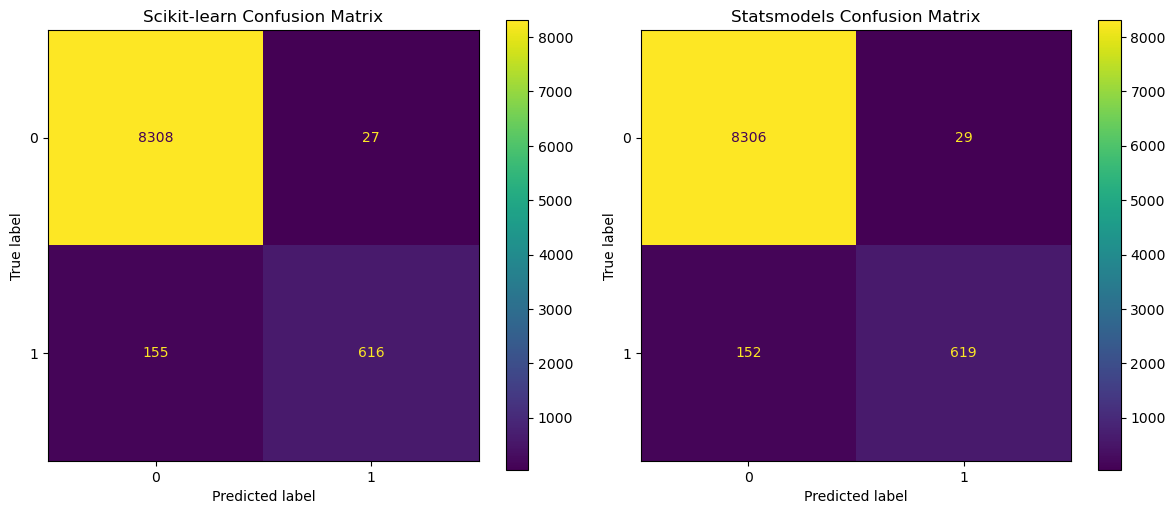

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_sklearn = confusion_matrix(Y_test, y_prd)
ConfusionMatrixDisplay(cm_sklearn).plot(ax=axes[0])
axes[0].set_title('Scikit-learn Confusion Matrix')

cm_sm = confusion_matrix(Y_test, y_pred_sm)
ConfusionMatrixDisplay(cm_sm).plot(ax=axes[1])
axes[1].set_title('Statsmodels Confusion Matrix')

plt.tight_layout()
plt.show()

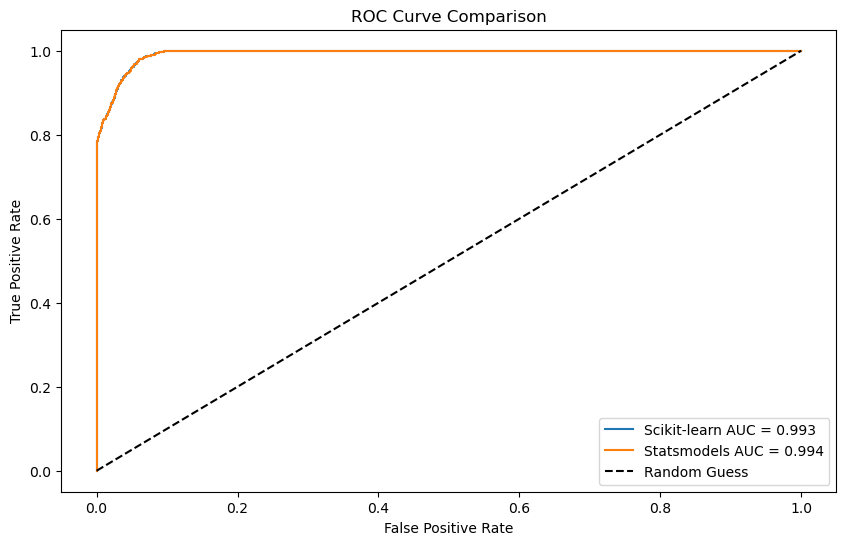

In [91]:
y_prob_sklearn = model.predict_proba(X_test)[:, 1]
y_prob_sm = Result_sm_model.predict(X_test_sm)

fpr_sklearn, tpr_sklearn, _ = roc_curve(Y_test, y_prob_sklearn)
fpr_sm, tpr_sm, _ = roc_curve(Y_test, y_prob_sm)

auc_sklearn = roc_auc_score(Y_test, y_prob_sklearn)
auc_sm = roc_auc_score(Y_test, y_prob_sm)

plt.figure(figsize=(10, 6))
plt.plot(fpr_sklearn, tpr_sklearn, label=f'Scikit-learn AUC = {auc_sklearn:.3f}')
plt.plot(fpr_sm, tpr_sm, label=f'Statsmodels AUC = {auc_sm:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

fpr_sklearn, tpr_sklearn, _ = roc_curve(y_test, y_prob_sklearn)
fpr_sm, tpr_sm, _ = roc_curve(y_test, y_prob_sm)